In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import os
os.makedirs('/content/drive/MyDrive/bank_project/outputs', exist_ok=True)

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

print("loaded")

loaded


In [29]:
df = pd.read_csv('/content/drive/MyDrive/bank_project/bank-full.csv', sep=';')
print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [30]:
print(df.columns.tolist())
print(df.dtypes)
print(df.describe())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000 

In [31]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df['y'].value_counts())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
0
y
no     39922
yes     5289
Name: count, dtype: int64


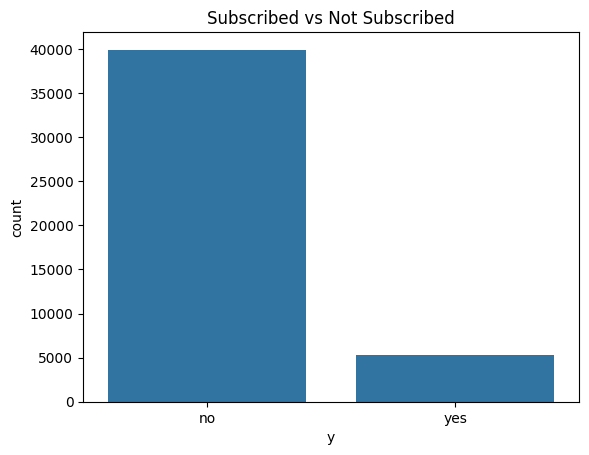

In [32]:
sns.countplot(x='y', data=df)
plt.title('Subscribed vs Not Subscribed')
plt.show()

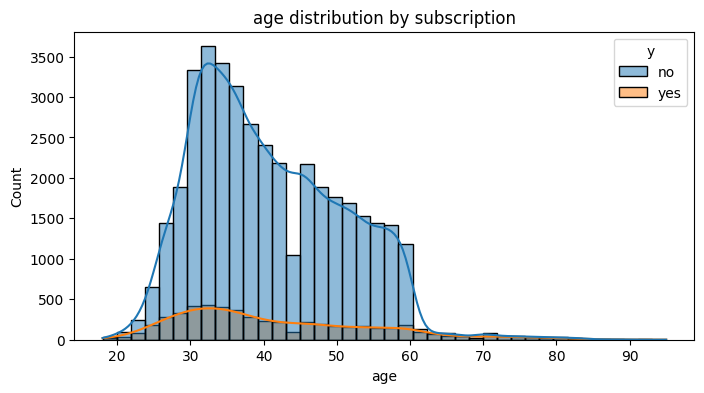

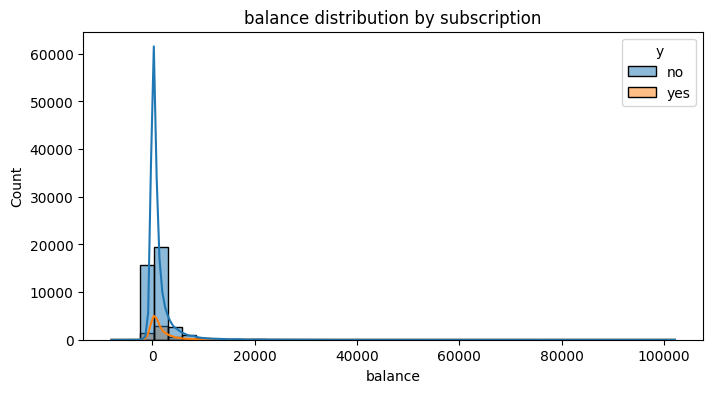

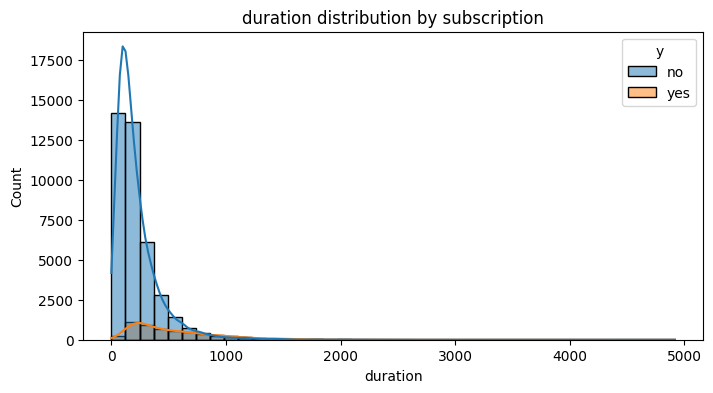

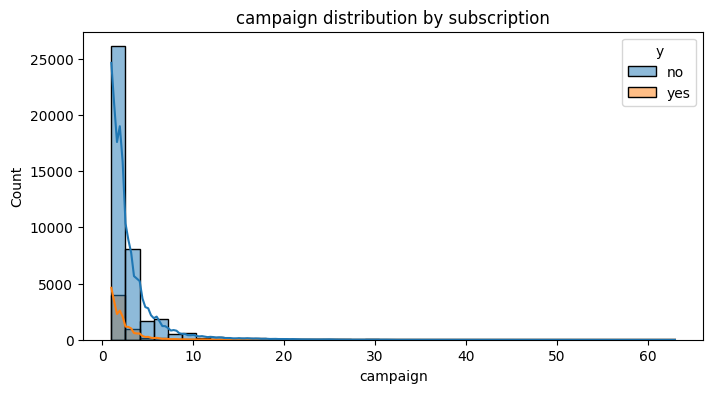

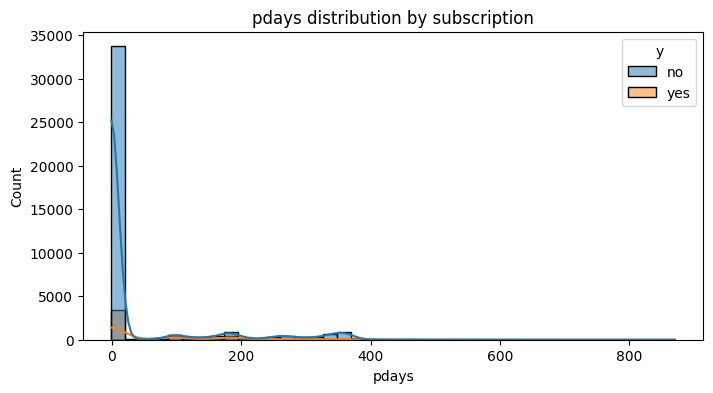

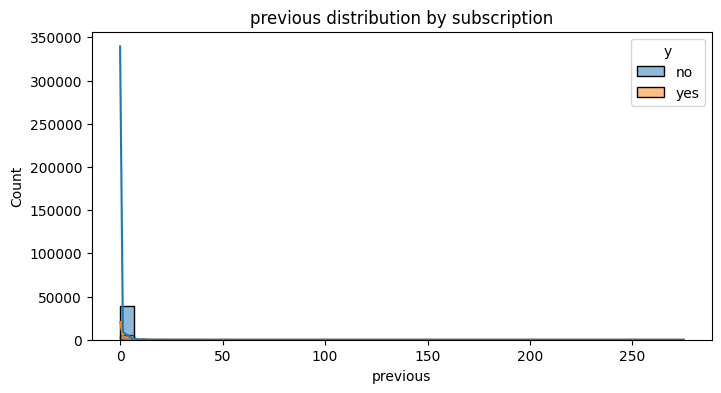

In [33]:
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=col, hue='y', bins=40, kde=True)
    plt.title(f'{col} distribution by subscription')
    plt.show()

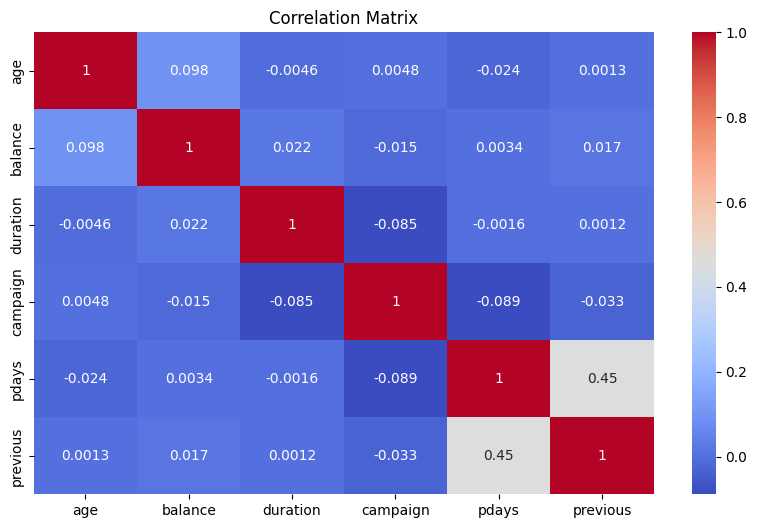

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [35]:
df.dropna(inplace=True)
print(df.shape)

(45211, 17)


In [36]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})
print(df['y'].value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [37]:
cat_cols = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'month', 'poutcome']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(df.shape)
df.head()

(45211, 43)


,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,0,False,True,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,0,True,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True


In [38]:
X = df.drop('y', axis=1)
y = df['y']

print(X.shape)
print(y.shape)

(45211, 42)
(45211,)


In [39]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print(f"Temp (train+val): {X_temp.shape}")
print(f"Test: {X_test.shape}")

Temp (train+val): (38429, 42)
Test: (6782, 42)


In [40]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (31665, 42)
Validation: (6764, 42)
Test: (6782, 42)


In [41]:
print("Train labels:\n", y_train.value_counts())
print("Val labels:\n", y_val.value_counts())
print("Test labels:\n", y_test.value_counts())

Train labels:
 y
0    27960
1     3705
Name: count, dtype: int64
Val labels:
 y
0    5973
1     791
Name: count, dtype: int64
Test labels:
 y
0    5989
1     793
Name: count, dtype: int64


In [43]:
train_df = X_train.copy();
train_df['y'] = y_train.values

val_df   = X_val.copy();
val_df['y']   = y_val.values

test_df  = X_test.copy();
test_df['y']  = y_test.values

train_df.to_csv('/content/drive/MyDrive/bank_project/outputs/train.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/bank_project/outputs/val.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/bank_project/outputs/test.csv', index=False)
print("Done")

Done
